Here, we preprocess the [immune dictionary](https://doi.org/10.1038/s41586-023-06816-9) dataset as described in scPerturb in anticipation that datasets from scPerturb will also be used. rds files are downloaded from the Immune Dictionary [download](https://www.immune-dictionary.org/app/home) page.

In [14]:
import os

import scanpy as sc
import anndata as ad

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.metrics import normalized_mutual_info_score as nmi
import omnipath as op

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings(action='ignore', module='pandas')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='ipykernel')
warnings.filterwarnings(action='ignore', category=FutureWarning, module='scanpy')
warnings.filterwarnings(action='ignore', category=UserWarning, module='scanpy')

import sys
sclembas_path = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas_path))
from scLEMBAS.preprocess import get_tf_activity, embed_tf_activity, transform_tf_activity, tf_to_adata
from scLEMBAS import io

In [3]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'

In [3]:
quick_run = False # whether to subsample data and use quicker/less mem intensive (less accurate) versions of parameters

quick_dict = {'quick': {'perm': int(10), 'n_samples': int(1e3), 'batch_size': int(1e3)},
             'full': {'perm': int(1e3), 'n_samples': None, 'batch_size': int(1e4)}}
if quick_run: 
    run_key = 'quick'
else:
    run_key = 'full'

In [4]:
# grid search params
use_raw = False
# impute = True

In [5]:
directory_names = [
    #data_path,
    #os.path.join(data_path, 'raw'), os.path.join(data_path, 'raw', 'immune_dictionary'),
    os.path.join(data_path, 'interim'), os.path.join(data_path, 'interim', 'immune_dictionary_h5ad'),
    os.path.join(data_path, 'processed'), os.path.join(data_path, 'figures')
]

for directory_name in directory_names:
    if not os.path.exists(directory_name):
        os.makedirs(directory_name)


# Load Files

In [6]:
# h5ad_in_path = os.path.join(data_path, 'interim', 'immune_dictionary_h5ad')
# file_names = os.listdir(h5ad_in_path)

# imm_d = {}
# for file_name in file_names:
#     cell_type = file_name.split('ref_data_')[1].split('.h5ad')[0]
#     adata = sc.read_h5ad(os.path.join(h5ad_in_path, file_name)) # Seurat counts slot in adata.raw.X, data slot in adata.X
#     imm_d[cell_type] = adata
# adata = ad.concat(list(imm_d.values()),  join="outer")

# sco = sorted(adata.obs.seurat_clusters.unique())
# adata.obs.seurat_clusters = pd.Categorical(adata.obs.seurat_clusters,
#                                            categories=sco,
#                                            ordered=True)

# adata.write_h5ad(os.path.join(data_path, 'interim', 'id_all.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'interim', 'id_all.h5ad'))

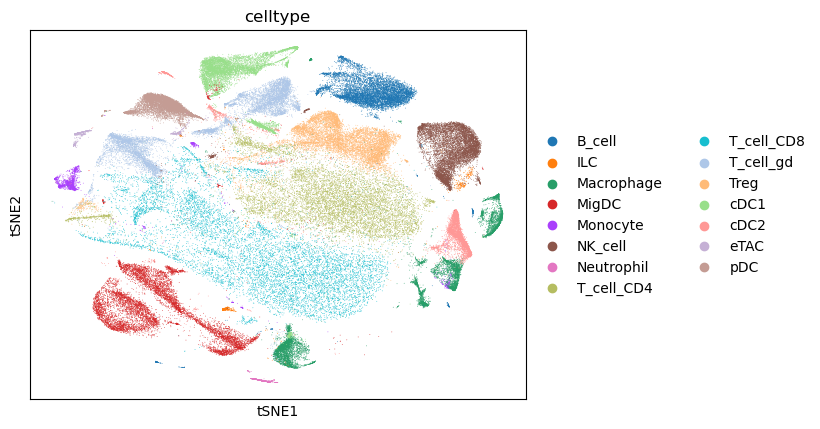

In [8]:
sc.pl.tsne(adata, color='celltype')

<font color='red'>Will probably want to re-process the data from raw fastqs or atleast from raw UMI counts at some point</font>

In [11]:
# sc.pp.neighbors(adata)
# sc.tl.umap(adata)
# adata.write_h5ad(os.path.join(data_path, 'processed', 'id_umap_all.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'id_umap_all.h5ad'))

# Get TF activity estimates:

In [10]:
if quick_run:
    adata = sc.pp.subsample(adata, n_obs = quick_dict[run_key]['n_samples'], copy = True, random_state = seed) 

kwargs = {'args' : {'wsum' : {'times': quick_dict[run_key]['perm'], 'batch_size': quick_dict[run_key]['batch_size']},
                       'ulm' : {'batch_size': quick_dict[run_key]['batch_size']}, 
                        'mlm': {'batch_size': quick_dict[run_key]['batch_size']}
                       }}
# kwargs['methods'] = ['lm', 'ulm', 'wsum', 
# kwargs['cns_metds'] = ['lm', 'ulm', 'wsum_norm']
adata = get_tf_activity(adata, organism = 'mouse', grn = 'collectri', verbose = True,
                consensus = True, hvg = False,
                min_n = 5, use_raw = use_raw, filter_pvals = False, pval_thresh = 0.05, **kwargs)
adata.write_h5ad(os.path.join(data_path, 'interim', 'expr_scored.h5ad'))


In [4]:
adata = sc.read_h5ad(os.path.join(data_path, 'interim', 'expr_scored.h5ad'))
fn_csv = os.path.join(data_path, 'interim', 'TF_activity.csv') 
for key in adata.obsm:
    if key.endswith('estimate') or key.endswith('pvals'):
        fn_csv_ = fn_csv.replace('TF_activity', key + '_TF_activity')
        adata.obsm[key].to_csv(fn_csv_)

        if key == 'consensus_estimate':
            transformed_consensus = transform_tf_activity(adata.obsm[key])

adata.obsm['consensus_estimate_transformed'] = transformed_consensus
tf_adata = preprocess.tf_to_adata(adata, estimate_key = 'consensus_estimate_transformed')

In [10]:
for key in adata.obsm:
    if key.endswith('estimate') or key.endswith('pvals'):
        fn_csv_ = fn_csv.replace('TF_activity', key + '_TF_activity')
        adata.obsm[key].to_csv(fn_csv_)

        if key == 'consensus_estimate':
            transformed_consensus = transform_tf_activity(adata.obsm[key])
            
adata.obsm['consensus_estimate_transformed'] = transformed_consensus
tf_adata = tf_to_adata(adata, estimate_key = 'consensus_estimate_transformed')

In [16]:
embed_tf_activity(tf_adata = tf_adata, scanpy_pca = False)

/home/hmbaghda/Projects/scLEMBAS/scLEMBAS/preprocess.py:250: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata = tf_adata) # cluster


In [17]:
io.write_tfad(tf_adata, file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

In [11]:
tf_adata = io.read_tfad(file_name = os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

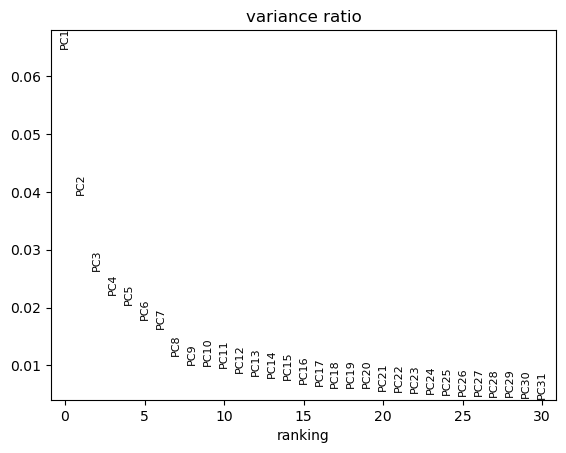

The elbow was automatically identified at PC 9


In [18]:
sc.pl.pca_variance_ratio(tf_adata)
print('The elbow was automatically identified at PC {}'.format(tf_adata.uns['pca']['pca_rank']))

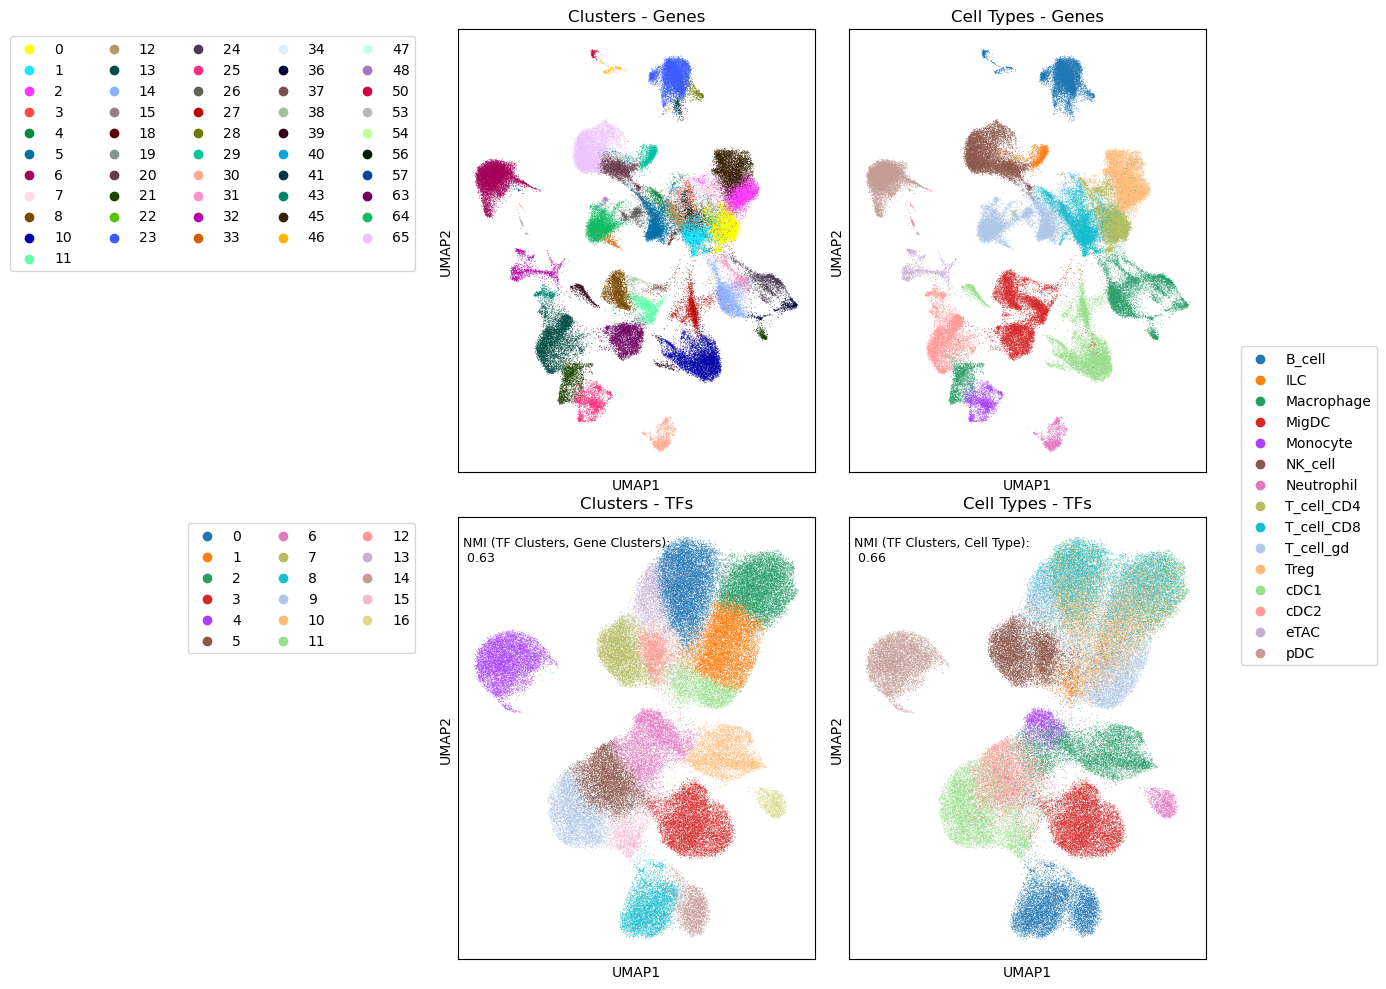

In [19]:
fig, ax = plt.subplots(ncols = 2, nrows = 2, figsize = (15, 10))

sc.pl.umap(adata, color='seurat_clusters', ax = ax[0,0], show = False)
ax[0,0].set_title('Clusters - Genes')
ax[0,0].legend(bbox_to_anchor=(-0.1, 1), ncol = 5, bbox_transform=ax[0,0].transAxes)

sc.pl.umap(adata, color='celltype', ax = ax[0,1], show = False)
ax[0,1].set_title('Cell Types - Genes')
ax[0, 1].legend(bbox_to_anchor=(1.5, 0.3), bbox_transform=ax[0,1].transAxes)

sc.pl.umap(tf_adata, color='TF_clusters', ax = ax[1,0], show = False)
ax[1,0].set_title('Clusters - TFs')
ax[1,0].legend(bbox_to_anchor=(-0.1, 1), bbox_transform=ax[1,0].transAxes, ncol = 3)
ax[1,0].annotate('NMI (TF Clusters, Gene Clusters):\n {:.2f}'.format(nmi(tf_adata.obs.TF_clusters, tf_adata.obs.seurat_clusters)),
                xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

sc.pl.umap(tf_adata, color='celltype', ax = ax[1,1], show = False)
ax[1,1].set_title('Cell Types - TFs')
ax[1,1].legend().set_visible(False)
ax[1,1].annotate('NMI (TF Clusters, Cell Type):\n {:.2f}'.format(nmi(tf_adata.obs.TF_clusters, tf_adata.obs.celltype)),
                xy = (0.015, 0.9), xycoords='axes fraction', fontsize = 9)

fig.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

# for presentation:

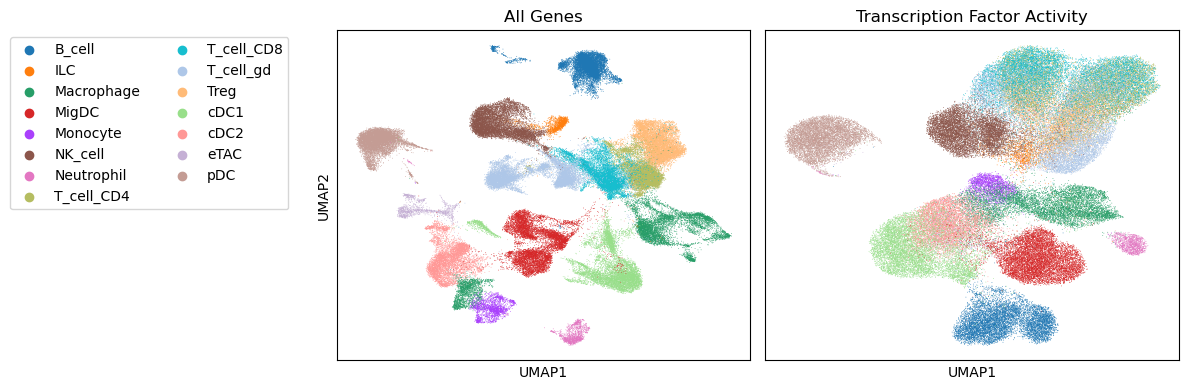

In [20]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 4))

sc.pl.umap(adata, color='celltype', ax = ax[0], show = False)
ax[0].set_title('All Genes')
ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 2, bbox_transform=ax[0].transAxes)

sc.pl.umap(tf_adata, color='celltype', ax = ax[1], show = False)
ax[1].set_title('Transcription Factor Activity')
ax[1].set_ylabel('').set_visible(False)
ax[1].legend(bbox_to_anchor=(-0.1, 1), ncol = 2, bbox_transform=ax[1].transAxes)
ax[1].legend().set_visible(False)

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', .png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

# for fellowships:

In [9]:
sc.tl.tsne(adata = tf_adata) 

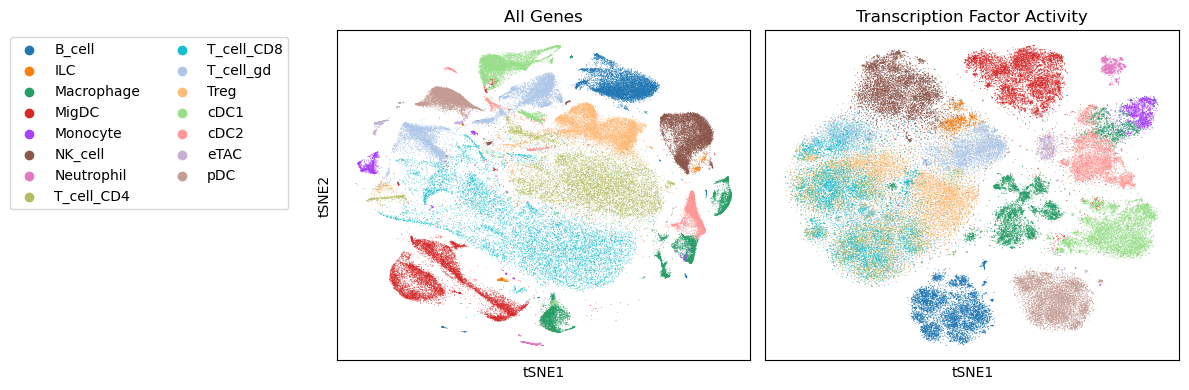

In [23]:
fig, ax = plt.subplots(ncols = 2, figsize = (12, 4))

sc.pl.tsne(adata, color='celltype', ax = ax[0], show = False)
ax[0].set_title('All Genes')
ax[0].legend(bbox_to_anchor=(-0.1, 1), ncol = 2, bbox_transform=ax[0].transAxes)

sc.pl.tsne(tf_adata, color='celltype', ax = ax[1], show = False)
ax[1].set_title('Transcription Factor Activity')
ax[1].set_ylabel('').set_visible(False)
ax[1].legend(bbox_to_anchor=(-0.1, 1), ncol = 2, bbox_transform=ax[1].transAxes)
ax[1].legend().set_visible(False)

fig.tight_layout()
plt.savefig(fname = os.path.join(data_path, 'figures', 'fellowship_figure_XX.png'), 
            transparent = True, 
            bbox_inches = 'tight')
plt.show()